Normalization factors (per T_period):
{64: 2945787.33, 128: 2947006.67, 256: 2967444.0, 512: 3017228.33, 1024: 2957486.0}


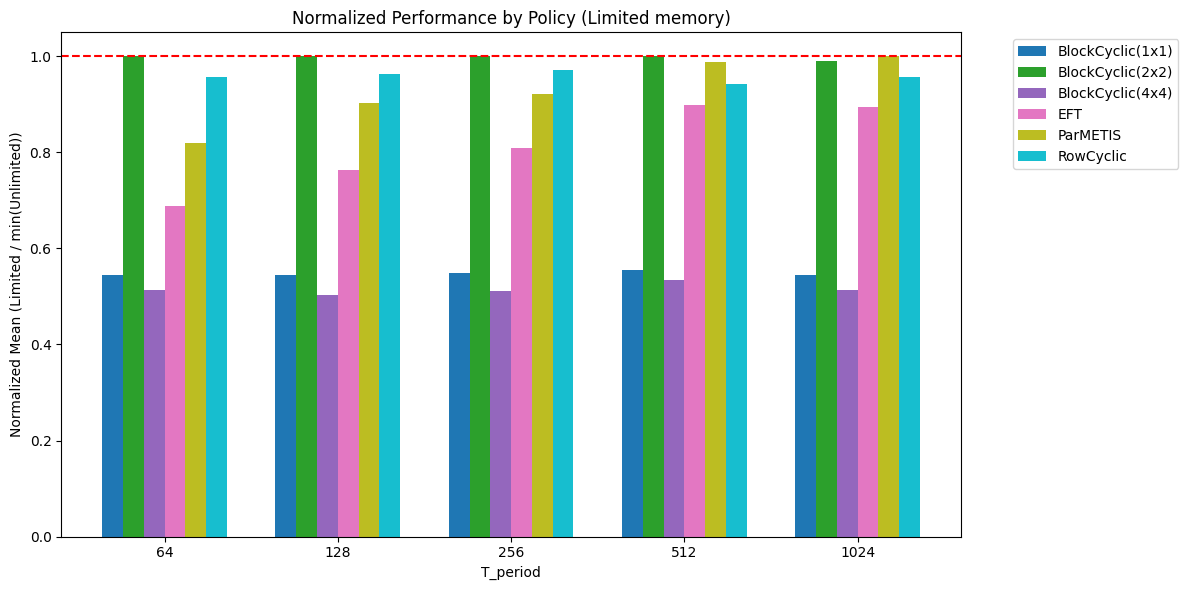

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# === Load and clean ===
df = pd.read_csv("/home/cc/task4feedback_torchrl/experiments/10-1-lcorners/detailed_results.csv")
df = df[df["Policy"] != "Policy"]  # remove repeated header rows
df["Mean"] = df["Mean"].astype(float)

# === Define T_periods ===
T_periods = [64, 128, 256, 512, 1024]

rows_per_chunk = len(df) // (len(T_periods) * 2)
chunks = []
for i, T in enumerate(T_periods):
    start = i * 2 * rows_per_chunk
    limited = df.iloc[start : start + rows_per_chunk].copy()
    unlimited = df.iloc[start + rows_per_chunk : start + 2 * rows_per_chunk].copy()
    limited["Memory"] = "Limited"
    unlimited["Memory"] = "Unlimited"
    limited["T_period"] = T
    unlimited["T_period"] = T
    chunks.append((limited, unlimited))

# === Combine all data ===
plot_data = []
for limited, unlimited in chunks:
    plot_data.append(limited)
    plot_data.append(unlimited)
df_plot = pd.concat(plot_data, ignore_index=True)

# === Compute normalization factors ===
# For each T_period, find the minimum Mean among all Unlimited runs (across all policies)
normalizers = df_plot[df_plot["Memory"] == "Unlimited"].groupby("T_period")["Mean"].min().to_dict()

# Example: normalizers = {64: 12.3, 128: 15.6, ...}
# You can print to verify
print("Normalization factors (per T_period):")
print(normalizers)

# === Apply normalization to Limited data ===
# Keep only Limited rows for plotting
df_limited = df_plot[df_plot["Memory"] == "Limited"].copy()

# Normalize Mean values by the corresponding Unlimited minimum
df_limited["Normalized"] = df_limited.apply(lambda r: normalizers[r["T_period"]] / r["Mean"], axis=1)

# === Plot normalized Limited data ===
plt.figure(figsize=(12, 6))

policies = sorted(df_limited["Policy"].unique())
bar_width = 0.12

x = np.arange(len(T_periods))  # one group per T_period

# Assign consistent colors per policy
colors = plt.cm.tab10(np.linspace(0, 1, len(policies)))
policy_colors = {p: colors[i] for i, p in enumerate(policies)}

# Offset bars within each group
offsets = {p: (i - (len(policies) - 1) / 2) * bar_width for i, p in enumerate(policies)}

added_labels = set()

for p in policies:
    for gi, T in enumerate(T_periods):
        sub = df_limited[(df_limited["Policy"] == p) & (df_limited["T_period"] == T)]
        if sub.empty:
            continue

        y = float(sub["Normalized"].iloc[0])
        xpos = x[gi] + offsets[p]

        label_text = p
        if label_text not in added_labels:
            plt.bar([xpos], [y], bar_width, color=policy_colors[p], label=label_text)
            added_labels.add(label_text)
        else:
            plt.bar([xpos], [y], bar_width, color=policy_colors[p])

# === Labels and legend ===
plt.xticks(x, [str(T) for T in T_periods])
plt.xlabel("T_period")
plt.ylabel("Normalized Mean (Limited / min(Unlimited))")
plt.title("Normalized Performance by Policy (Limited memory)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.axhline(1.0, color="red", linestyle="--", linewidth=1.5, label="Unlimited baseline")
plt.tight_layout()

plt.show()

In [7]:
import itertools
import subprocess
import time
import argparse

list_of_ibs = [(0.1, 0.1), (1, 0.1), (1, 1), (10, 1), (10, 0.1), (100, 10)]

param = {}
for interior, boundary in list_of_ibs:
    if interior < boundary:
        continue
    param[(interior, boundary)] = (f"{595.5555555/interior:.7f}"[:-1], f"{0.25 / (interior / boundary)}")
for k, v in param.items():
    print(f"{k}: {v}")
print(param)


run_dict = {"lcorners": []}
# Interior, Boundary, Mem order

# run_dict["lcorners"].append((0.1, 0.1, "35e9", "BlockCyclic(2x2)", "Oracle(64)"))
# run_dict["lcorners"].append((1, 0.1, "100e9", "ParMETIS(1.03,0.0001001)", "EFT"))
# run_dict["lcorners"].append((1, 1, "35e9", "BlockCyclic(2x2)", "Colwise"))
# run_dict["lcorners"].append((10, 0.1, "105e9", "ParMETIS(1.05,0.0001001)", "BlockCyclic(2x2)"))
run_dict["lcorners"].append((10, 1, "95e9", "BlockCyclic(2x2)", "ParMETIS(1.04,10)"))
# run_dict["lcorners"].append((100, 10, "49e9", "ParMETIS(1.04,10)", "BlockCyclic(2x2)"))

# --- Core pool setup ---
# node0_cores = list(range(0, 36))  # even = NUMA node0
# node1_cores = list(range(108, 144))  # odd = NUMA node1
node0_cores = list(range(0, 80, 2))  # even = NUMA node0
node1_cores = list(range(1, 80, 2))  # odd = NUMA node1
all_cores = node0_cores + node1_cores
free_cores = set(all_cores)

running_jobs = []  # (proc, allocated_cores)

# --- Build jobs list from run_dict ---


jobs = []
for seed in range(1,21):
    for v in ["D"]:
        for k in run_dict.keys():
            # for dmem in [64e9, 80e9, 9999e9]:
            for dmem in [64e9]:
                for interior, boundary, mem, _, _ in run_dict[k]:
                    ib = param[(interior, boundary)]
                    prj_name = f"8x8x256_{k}_{interior}-{boundary}-1_IPDPS"
                    n_cores = 4
                    cmd = [
                        "python3",
                        "train.py",
                        "--config-name",
                        f"8x8x1024_dynamic_{k}_cnn",
                        f"wandb.project={prj_name}",
                        f"graph.config.level_memory={mem}",
                        f"wandb.name={v}_{int(dmem/1e9)}",
                        f"wandb.group={v}_{int(dmem/1e9)}",
                        f"seed={(seed+10)*100000000}",
                        f"system.mem={dmem}",
                        f"graph.config.arithmetic_intensity={ib[0]}",
                        f"graph.config.boundary_width={ib[1]}",
                    ]
                    jobs.append((n_cores, cmd))
                    print(f"{' '.join(cmd)}")


# --- Scheduler helpers ---
def allocate_cores(n):
    """Allocate n free cores from the same NUMA node."""
    global free_cores
    node0_free = [c for c in node0_cores if c in free_cores]
    node1_free = [c for c in node1_cores if c in free_cores]

    # Prefer node0 if enough free cores, else node1
    if len(node0_free) >= n:
        selected = node0_free[:n]
    elif len(node1_free) >= n:
        selected = node1_free[:n]
    else:
        return None

    for c in selected:
        free_cores.remove(c)
    return selected


# --- Job launcher loop ---
for n, cmd in jobs:
    cores = allocate_cores(n)
    core_str = ",".join(map(str, cores))
    full_cmd = ["taskset", "-c", core_str] + cmd
    print(f"{' '.join(full_cmd)}")

(0.1, 0.1): ('5955.555555', '0.25')
(1, 0.1): ('595.555555', '0.025')
(1, 1): ('595.555555', '0.25')
(10, 1): ('59.555555', '0.025')
(10, 0.1): ('59.555555', '0.0025')
(100, 10): ('5.955555', '0.025')
{(0.1, 0.1): ('5955.555555', '0.25'), (1, 0.1): ('595.555555', '0.025'), (1, 1): ('595.555555', '0.25'), (10, 1): ('59.555555', '0.025'), (10, 0.1): ('59.555555', '0.0025'), (100, 10): ('5.955555', '0.025')}
python3 train.py --config-name 8x8x1024_dynamic_lcorners_cnn wandb.project=8x8x256_lcorners_10-1-1_IPDPS graph.config.level_memory=95e9 wandb.name=D_64 wandb.group=D_64 seed=1100000000 system.mem=64000000000.0 graph.config.arithmetic_intensity=59.555555 graph.config.boundary_width=0.025
python3 train.py --config-name 8x8x1024_dynamic_lcorners_cnn wandb.project=8x8x256_lcorners_10-1-1_IPDPS graph.config.level_memory=95e9 wandb.name=D_64 wandb.group=D_64 seed=1200000000 system.mem=64000000000.0 graph.config.arithmetic_intensity=59.555555 graph.config.boundary_width=0.025
python3 train.p